In [21]:
from torch_geometric.datasets import Planetoid
from torch_geometric.transforms import NormalizeFeatures

dataset = Planetoid(root="tmp/planetoid", name="PubMed", transform=NormalizeFeatures())

# let's inspect the data
print(f"The data has {len(dataset)} graph/s.")
print(f"The graph has {dataset[0].num_nodes} nodes.")
print(f"The graph has {dataset[0].num_edges} edges.")
print(f"The graph has an average node degree of {dataset[0].num_edges/dataset[0].num_nodes:.2f}.")
print(f"The graph is undirected {dataset[0].is_undirected()}.")
print(f"The graph has isolated nodes {dataset[0].has_isolated_nodes()}.")
print(f"The graph nodes have {dataset.num_features} features.")
print(f"The graph has {dataset.num_classes} classes.")
print(f"The label rate in train data is: {dataset[0].train_mask.sum()/dataset[0].num_nodes:.3f}.")

The data has 1 graph/s.
The graph has 19717 nodes.
The graph has 88648 edges.
The graph has an average node degree of 4.50.
The graph is undirected True.
The graph has isolated nodes False.
The graph nodes have 500 features.
The graph has 3 classes.
The label rate in train data is: 0.003.


In [ ]:
from torch_geometric.loader import ClusterData, ClusterLoader 
import torch
import torch.nn as nn
from torch_geometric.nn import GCNConv
from tqdm import tqdm

# train - val - test
num_parts = 500
cluster_data = ClusterData(dataset[0], num_parts=num_parts)
train_loader = ClusterLoader(cluster_data, batch_size=64, shuffle=True)
test_batch = [*train_loader][0]

# model generation

class GCN(nn.Module):
    def __init__(self, in_channel: int, hidden_channel: int, out_channel: int, num_classes: int, p: float):
        super().__init__()

        self.conv_in = GCNConv(in_channel, hidden_channel, add_self_loops=True)
        self.conv_out = GCNConv(hidden_channel, out_channel, add_self_loops=True)

        self.classifer_head = nn.Linear(out_channel, num_classes)
        self.dropout = nn.Dropout(p)
        self.relu = nn.ReLU()

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor):
        x = self.conv_in(x, edge_index)
        x = self.relu(x)
        x = self.dropout(x)

        x = self.conv_out(x, edge_index)
        h = self.relu(x)
        x = self.dropout(h)

        x = self.classifer_head(x)

        return x, h
    
def train(model: GCN, optimizer: torch.optim, data: ClusterLoader, criterion: nn.CrossEntropyLoss, ):
    model.train()
    optimizer.zero_grad()
    out, _ = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

def val(model: GCN, data: ClusterLoader, criterion: nn.CrossEntropyLoss):
    model.eval()
    with torch.no_grad():
        out, _ = model(data.x, data.edge_index)
        loss = criterion(out[data.val_mask], data.y[data.val_mask])
        return loss.item()

def acc(model:GCN, data: ClusterLoader, mask: torch.Tensor):
    model.eval()
    with torch.no_grad():
        out, _ = model(data.x, data.edge_index)
        label = torch.argmax(out[mask], dim=1)
        return (label == data.y[mask]).float().mean().item()
    
model = GCN(in_channel=500, hidden_channel=64, out_channel=32, num_classes=3, p=0.5)
out, h = model(test_batch.x, test_batch.edge_index)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

train(model, optimizer, test_batch, criterion)
val(model, test_batch, criterion)
acc(model, test_batch, test_batch.train_mask)

def train_val_test(epochs: int, train_loader: ClusterLoader, model: GCN, optimizer: torch.optim, criterion: nn.CrossEntropyLoss):
    train_loss = []
    val_loss = []

    train_acc = []
    val_acc = []
    test_acc = []

    for _ in tqdm(range(epochs)):
        t_loss = 0
        v_loss = 0

        t_acc = 0
        v_acc = 0

        for batch in train_loader:
            t_loss += train(model, optimizer, batch, criterion)
            t_acc += acc(model, batch, batch.train_mask)

        for batch in train_loader:
            v_loss += val(model, batch, criterion)
            v_acc += acc(model, batch, batch.val_mask)

        t_loss /= len(train_loader)
        v_loss /= len(train_loader)
        t_acc /= len(train_loader)
        v_acc /= len(train_loader)

        train_loss.append(t_loss)
        val_loss.append(v_loss)
        
        train_acc.append(t_acc)
        val_acc.append(v_acc)

    test_acc = 0
    for batch in train_loader:
        test_acc += acc(model, batch, batch.test_mask)
    test_acc /= len(train_loader)

    return {
        "model": model,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_acc": train_acc,
        "val_acc": val_acc,
        "test_acc": test_acc
    }

Computing METIS partitioning...
Done!


In [96]:
epochs = 100

output = train_val_test(epochs, train_loader, model, optimizer, criterion)

100%|██████████| 100/100 [00:26<00:00,  3.71it/s]


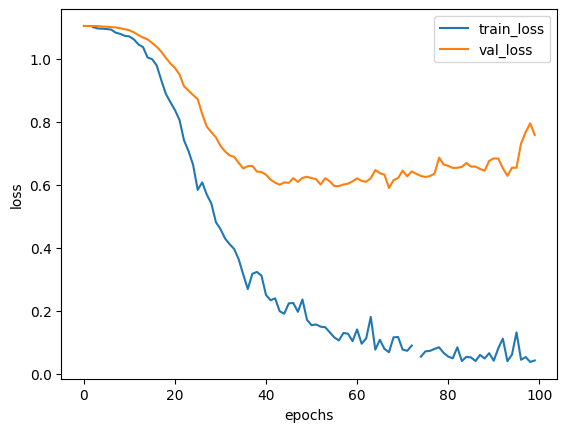

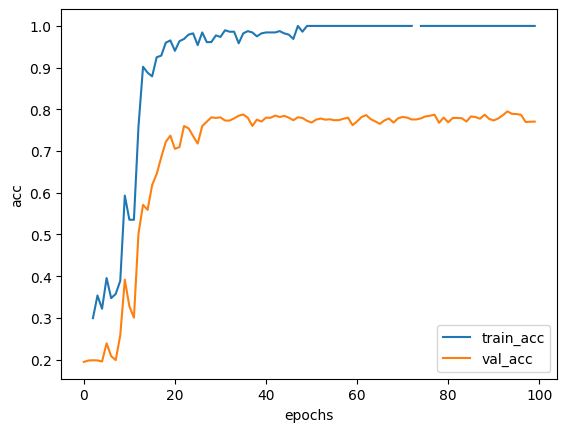

In [97]:
import matplotlib.pyplot as plt

plt.plot(output["train_loss"], label="train_loss")
plt.plot(output["val_loss"], label="val_loss")
plt.legend()
plt.xlabel("epochs")
plt.ylabel("loss")
plt.show()

plt.plot(output["train_acc"], label="train_acc")
plt.plot(output["val_acc"], label="val_acc")
plt.xlabel("epochs")
plt.ylabel("acc")
plt.legend()

plt.show()